# Method Comparison — Stage 6 Oracle Simulation

Generic analysis notebook for any model / workload / tree config produced
by the Stage 6 pipeline. Auto-discovers all `{workload}_steps{N}/`
directories under the selected `MODEL_DIR`, then renders bar charts /
scatter / budget sensitivity for one configuration at a time.

**Usage**:
1. Set `MODEL_DIR` to the model's output root (e.g. `../results/qwen3_14b`).
2. Pick `SELECTED` from the auto-discovered keys (printed when the
   config cell runs).
3. Optionally toggle `USE_REAL_COST` and `RATIO_CHART_BUDGET`.

Sections 1–6 operate on the selected config. Section 7 overlays the
selected workload's steps sweep (e.g. specbench steps={2,4,6,8}).
Section 8 compares workloads at the same steps.

In [187]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 100,
})

In [188]:
# ========== SELECT CONFIG AND COST MODE HERE ==========
import os
import re
from pathlib import Path

# >>> CHANGE THESE <<<
MODEL_DIR = "../results/qwen3_14b"
# MODEL_DIR = "../results/mango3/qwen3_8b"
USE_REAL_COST = True       # True = measured latencies, False = ratio-based
RATIO = 0.1                # only used when USE_REAL_COST = False
RATIO_CHART_BUDGET = 256   # reference budget for the ratio-sweep chart (§4)
# Leave SELECTED = None to auto-pick the first available key,
# or set to a specific short key (e.g. "specbench_steps2", "bfcl_v4_req576-579").
# SELECTED = "specbench_req0-3"
SELECTED = "specbench_steps8_draftpt_req0-4"
# SELECTED = "bfcl_v4_steps6_draftpt_req0-4"
# SELECTED = "swebench_steps6"

# Auto-discover any sub-directory that contains tree_oracle_sim.json
# (or tree_oracle_sim_ours.json — takes priority when both exist).
# Understands both Phase 5 `{workload}_steps{N}` and legacy
# `{workload}_req{start}-{end}` naming conventions.
WORKLOAD_OPTIONS = {}
_rgx_steps = re.compile(r"^(.+)_steps(\d+)$")
_rgx_req   = re.compile(r"^(.+)_req([0-9]+-[0-9]+)$")

def _parse_dir_name(name):
    """Return (workload, axis, axis_value) or (name, None, None)."""
    m = _rgx_steps.match(name)
    if m:
        return m.group(1), "steps", int(m.group(2))
    m = _rgx_req.match(name)
    if m:
        return m.group(1), "req", m.group(2)
    return name, None, None

_base = Path(MODEL_DIR)
if _base.exists():
    for sub in sorted(_base.iterdir()):
        if not sub.is_dir():
            continue
        # Prefer tree_oracle_sim_ours.json if present (re-simulation with our cost)
        ours = sub / "tree_oracle_sim_ours.json"
        default = sub / "tree_oracle_sim.json"
        path = ours if ours.exists() else default
        if not path.exists():
            continue
        workload, axis, ax_val = _parse_dir_name(sub.name)
        if axis == "steps":
            tag = f"steps={ax_val}"
        elif axis == "req":
            tag = f"req{ax_val}"
        else:
            tag = ""
        label = f"{workload} {tag}".strip()
        WORKLOAD_OPTIONS[sub.name] = (label, str(path))

if not WORKLOAD_OPTIONS:
    raise RuntimeError(
        f"No tree_oracle_sim*.json found under {MODEL_DIR}.")

if SELECTED is None:
    SELECTED = next(iter(WORKLOAD_OPTIONS))
if SELECTED not in WORKLOAD_OPTIONS:
    raise RuntimeError(
        f"SELECTED='{SELECTED}' not found. Available: {list(WORKLOAD_OPTIONS.keys())}")

print(f"Available configs: {list(WORKLOAD_OPTIONS.keys())}")
print(f"→ SELECTED = '{SELECTED}'")
print()

workload_name, workload_path = WORKLOAD_OPTIONS[SELECTED]
with open(workload_path) as f:
    data = json.load(f)

# vanilla_step_ms: prefer per-run latency_config_ours (if present), then
# per-run latency_config, then shared model-level config.
latency_candidates = [
    Path(workload_path).parent / "latency_config_ours.json",
    Path(workload_path).parent / "latency_config.json",
    Path(MODEL_DIR) / "latency_config.json",
]
vanilla_ms = None
for lp in latency_candidates:
    if not lp.exists():
        continue
    try:
        with open(lp) as f:
            lc = json.load(f)
        vanilla_ms = lc['vanilla_step_ms']
        print(f"Loaded vanilla_step_ms={vanilla_ms:.3f} from {lp}")
        break
    except Exception:
        continue
if vanilla_ms is None:
    vanilla_ms = float(data.get('latency', {}).get('vanilla_step_ms', 0.0)) or 1.0
    print(f"Using fallback vanilla_step_ms={vanilla_ms:.3f}")

COST_LABEL = "real cost" if USE_REAL_COST else f"ratio={RATIO}"

print()
print(f"Workload: {SELECTED} — {workload_name}")
if USE_REAL_COST:
    print("Draft cost: REAL (measured latencies)")
else:
    print(f"Draft cost ratio: {RATIO} (step = verify × {1+RATIO:.2f})")
print(f"Ratio-chart reference budget (§4 only): B={RATIO_CHART_BUDGET}")

Available configs: ['bfcl_v4_steps2', 'bfcl_v4_steps4', 'bfcl_v4_steps6', 'bfcl_v4_steps8', 'specbench_steps2', 'specbench_steps4', 'specbench_steps6', 'specbench_steps8', 'specbench_steps8_draftpt_req0-4', 'swebench_steps2', 'swebench_steps4', 'swebench_steps6']
→ SELECTED = 'specbench_steps8_draftpt_req0-4'

Loaded vanilla_step_ms=28.233 from ../results/qwen3_14b/specbench_steps8_draftpt_req0-4/latency_config.json

Workload: specbench_steps8_draftpt_req0-4 — specbench_steps8_draftpt req0-4
Draft cost: REAL (measured latencies)
Ratio-chart reference budget (§4 only): B=256


In [189]:
# Parse budget table
df = pd.DataFrame(data["latency"]["budget_sweep"])

# Speedup key: real-cost or ratio-based
spd_suffix = "_speedup_real" if USE_REAL_COST else f"_speedup_r{RATIO}"

# Hide: Choose-One oracle methods are excluded from main charts.
HIDE_METHODS = {'c1', 'c1_e3sfx'}

# Always-at-max-budget: suffix (budget-independent, benefits from full tree)
MAX_BUDGET_METHODS = {'suffix'}

max_budget = int(df['budget'].max())
methods = []
for col in df.columns:
    if col.endswith(spd_suffix):
        name = col.replace(spd_suffix, '')
        if name.endswith('_always'):
            continue
        if name in HIDE_METHODS:
            continue
        if name in MAX_BUDGET_METHODS:
            row = df[df['budget'] == max_budget]
            idx = row.index[0]
        else:
            idx = df[col].idxmax()
        best_b = int(df['budget'].iloc[idx])
        mc = f'{name}_mat'
        methods.append({
            'method': name,
            'best_budget': best_b,
            'speedup': df[col].iloc[idx],
            'mat': df[mc].iloc[idx] if mc in df.columns else 0,
        })

mdf_all = pd.DataFrame(methods)

# Keep only best threshold per hybrid group
for prefix in ['hybrid_e3_t', 'hybrid_dm_t']:
    mask = mdf_all['method'].str.startswith(prefix)
    group = mdf_all[mask]
    if len(group) > 1:
        best_idx = group['speedup'].idxmax()
        drop_idx = group.index[group.index != best_idx]
        mdf_all = mdf_all.drop(drop_idx)

# ---------- Extension variant taxonomy ----------
def _ext_taxonomy(name):
    if not name.startswith('extension'):
        return None, None
    is_dm = name.startswith('extension_dmsfx')
    base = 'dm' if is_dm else 'e3'
    rest = name[len('extension_dmsfx'):] if is_dm else name[len('extension'):]
    if rest == '':
        fam = 'basic'
    elif rest == '_oracle':
        fam = 'oracle'
    elif rest.startswith('_by_count_score'):
        fam = 'count_score'
    elif rest.startswith('_by_count'):
        fam = 'count'
    elif rest.startswith('_by_scorelen'):
        fam = 'scorelen'
    elif rest.startswith('_by_score'):
        fam = 'score'
    elif rest.startswith('_by_minlen'):
        fam = 'minlen'
    elif rest.startswith('_by_ptopk'):
        fam = 'ptopk'
    elif rest.startswith('_by_product'):
        fam = 'product'
    elif rest.startswith('_by_pathprob'):
        fam = 'pathprob'
    elif rest.startswith('_by_topp'):
        fam = 'topp'
    elif rest.startswith('_by_dynsfx'):
        fam = 'dynsfx'
    else:
        fam = 'other'
    return base, fam

mdf_all['ext_base'], mdf_all['ext_family'] = zip(
    *mdf_all['method'].map(_ext_taxonomy))

mdf_ext = mdf_all[mdf_all['ext_base'].notna()].copy().reset_index(drop=True)

# Main chart scope: only the four extension entries — shown in this
# order via the ORDER index further below:
#   extension, extension_dmsfx, extension_oracle, extension_dmsfx_oracle.
MAIN_EXT_METHODS = ['extension', 'extension_dmsfx',
                    'extension_oracle', 'extension_dmsfx_oracle']

ext_main = mdf_all[mdf_all['method'].isin(MAIN_EXT_METHODS)].copy()
mdf = mdf_all[mdf_all['ext_base'].isna()].copy()
if len(ext_main) > 0:
    mdf = pd.concat([mdf, ext_main], ignore_index=True)
mdf = mdf.reset_index(drop=True)

# Labels
def make_label(name):
    labels = {
        'eagle3': 'EAGLE3',
        'suffix': 'Suffix',
        'draft_model': 'Draft Model',
        'extension': 'Extension (E3+Sfx)',
        'extension_dmsfx': 'Extension (DM+Sfx)',
        'extension_oracle': 'Ext(E3+Sfx) oracle',
        'extension_dmsfx_oracle': 'Ext(DM+Sfx) oracle',
        'extension_by_count': 'Ext(E3+Sfx,count)',
        'extension_dmsfx_by_count': 'Ext(DM+Sfx,count)',
    }
    if name in labels:
        return labels[name]
    if name.startswith('hybrid_e3'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->E3) t={t}'
    if name.startswith('hybrid_dm'):
        t = name.split('_t')[1]
        return f'Hybrid(Sfx->DM) t={t}'
    if name.startswith('extension_dmsfx_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(DM+Sfx,score) t={t}'
    if name.startswith('extension_by_score_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,score) t={t}'
    if name.startswith('extension_by_ptopk_k'):
        k = name.split('_k')[1]
        return f'Ext(E3+Sfx,ptopk) K={k}'
    if name.startswith('extension_by_product_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,prod) t={t}'
    if name.startswith('extension_by_pathprob_t'):
        t = name.split('_t')[1]
        return f'Ext(E3+Sfx,pathp) t={t}'
    if name.startswith('extension_by_topp_p'):
        p = name.split('_p')[1]
        return f'Ext(E3+Sfx,topp) p={p}'
    if name.startswith('extension_by_dynsfx_a'):
        a = name.split('_a')[1]
        return f'Ext(E3+Sfx,dynsfx) α={a}'
    return name

ORDER = [
    'eagle3', 'suffix', 'draft_model',
    'hybrid_e3', 'hybrid_dm',
    'extension', 'extension_dmsfx',
    'extension_by_count', 'extension_dmsfx_by_count',
    'extension_by_score', 'extension_dmsfx_by_score',
    'extension_by_ptopk', 'extension_by_product', 'extension_by_pathprob',
    'extension_by_topp', 'extension_by_dynsfx',
    'extension_oracle', 'extension_dmsfx_oracle',
]

def get_order(name):
    if name.startswith('hybrid_e3'):
        return ORDER.index('hybrid_e3')
    if name.startswith('hybrid_dm'):
        return ORDER.index('hybrid_dm')
    if name.startswith('extension_dmsfx_by_score'):
        return ORDER.index('extension_dmsfx_by_score')
    if name.startswith('extension_by_score'):
        return ORDER.index('extension_by_score')
    if name.startswith('extension_by_ptopk'):
        return ORDER.index('extension_by_ptopk')
    if name.startswith('extension_by_product'):
        return ORDER.index('extension_by_product')
    if name.startswith('extension_by_pathprob'):
        return ORDER.index('extension_by_pathprob')
    if name.startswith('extension_by_topp'):
        return ORDER.index('extension_by_topp')
    if name.startswith('extension_by_dynsfx'):
        return ORDER.index('extension_by_dynsfx')
    return ORDER.index(name) if name in ORDER else len(ORDER)

def get_color(name):
    if name == 'eagle3': return '#2ca02c'
    if name == 'suffix': return '#ff7f0e'
    if name == 'draft_model': return '#8c564b'
    if 'hybrid_e3' in name: return '#9467bd'
    if 'hybrid_dm' in name: return '#e377c2'
    if name == 'extension': return '#d62728'
    if name == 'extension_dmsfx': return '#fc8d8d'
    if name == 'extension_oracle': return '#7a0000'
    if name == 'extension_dmsfx_oracle': return '#a83232'
    if name == 'extension_by_count': return '#ef4040'
    if name == 'extension_dmsfx_by_count': return '#ffa0a0'
    if name.startswith('extension_dmsfx_by_score'): return '#c94a4a'
    if name.startswith('extension_by_score'): return '#a51717'
    if name.startswith('extension_by_ptopk'): return '#5a1616'
    if name.startswith('extension_by_product'): return '#8b0000'
    if name.startswith('extension_by_pathprob'): return '#b22222'
    if name.startswith('extension_by_topp'): return '#aa3333'
    if name.startswith('extension_by_dynsfx'): return '#cc5555'
    return '#7f7f7f'

mdf['label'] = mdf['method'].map(make_label)
mdf['color'] = mdf['method'].map(get_color)
mdf['order'] = mdf['method'].map(get_order)
mdf = mdf.sort_values('order').reset_index(drop=True)

print(f"Methods in main chart: {len(mdf)}, cost={COST_LABEL}")
print(mdf[['label', 'best_budget', 'speedup', 'mat']].to_string(index=False))
print()
print(f"Extension variants collected: {len(mdf_ext)}  "
      "(detailed comparison in §9)")

Methods in main chart: 9, cost=real cost
                 label  best_budget  speedup      mat
                EAGLE3           16 2.015891 1.304135
                Suffix          128 1.390424 0.397362
           Draft Model            1 1.205164 0.688061
Hybrid(Sfx->E3) t=10.0           16 2.043993 1.334161
 Hybrid(Sfx->DM) t=1.0            1 1.427436 0.711880
    Extension (E3+Sfx)            4 1.850931 1.260517
    Extension (DM+Sfx)            1 1.475729 1.076180
    Ext(E3+Sfx) oracle           16 2.313745 1.654905
    Ext(DM+Sfx) oracle            1 1.577669 1.210403

Extension variants collected: 68  (detailed comparison in §9)


## 1. Speedup Comparison

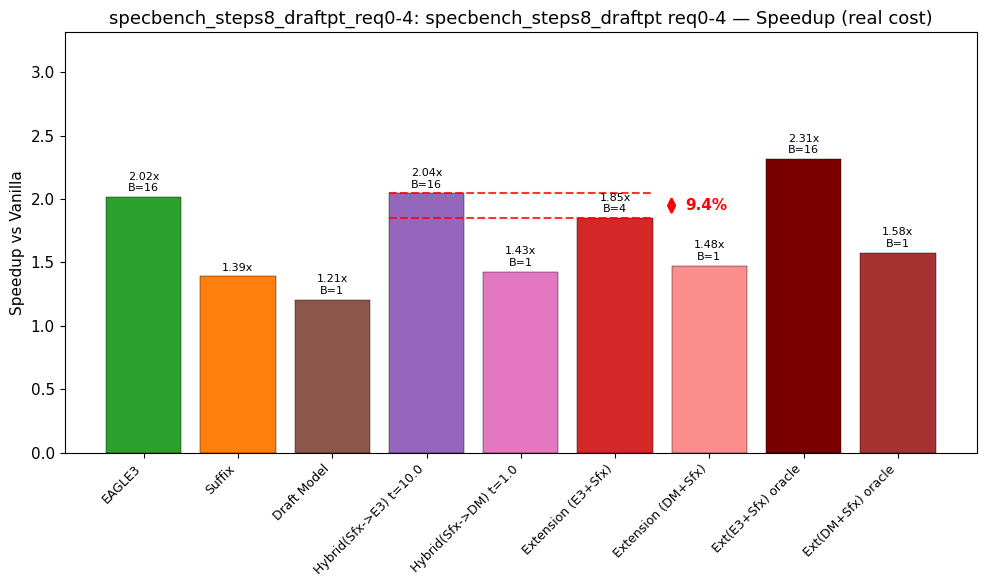

In [190]:
fig, ax = plt.subplots(figsize=(max(10, len(mdf) * 0.8), 6))

x = np.arange(len(mdf))
bars = ax.bar(x, mdf['speedup'].values, color=mdf['color'].values,
              edgecolor='black', linewidth=0.3)

_max_b = int(df['budget'].max())
for i, (spd, b) in enumerate(zip(mdf['speedup'].values, mdf['best_budget'].values)):
    if int(b) == _max_b:
        txt = f'{spd:.2f}x'
    else:
        txt = f'{spd:.2f}x\nB={b}'
    ax.text(i, spd + 0.03, txt, ha='center', va='bottom', fontsize=8)

# Gap annotation: best realistic extension (excluding oracle variants) vs
# best hybrid. The oracle methods are upper bounds (they assume knowing
# which suffix chains to verify beforehand) and so don't represent
# deployable settings — compare against practical extension instead.
def _is_hybrid(m):
    return (m.startswith('hybrid_e3_t') or m.startswith('hybrid_dm_t')) \
        and not m.endswith('_always')

def _is_realistic_extension(m):
    if not m.startswith('extension'):
        return False
    # Exclude the "oracle" variants (target verifies only accepted path).
    return not (m == 'extension_oracle' or m == 'extension_dmsfx_oracle')

methods_list = list(mdf['method'].values)
speedups_list = list(mdf['speedup'].values)

best_hyb = None
for i, m in enumerate(methods_list):
    if _is_hybrid(m):
        if best_hyb is None or speedups_list[i] > speedups_list[best_hyb]:
            best_hyb = i

best_ext = None
for i, m in enumerate(methods_list):
    if _is_realistic_extension(m):
        if best_ext is None or speedups_list[i] > speedups_list[best_ext]:
            best_ext = i

if best_hyb is not None and best_ext is not None:
    h_pos, e_pos = best_hyb, best_ext
    h_spd = speedups_list[h_pos]
    e_spd = speedups_list[e_pos]
    pct = abs((h_spd - e_spd) / max(h_spd, e_spd) * 100)

    x_lo, x_hi = sorted([h_pos, e_pos])
    ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)
    ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.4, colors='red',
              linestyles='--', alpha=0.8, linewidth=1.5)

    arrow_x = x_hi + 0.6
    ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
    ax.text(arrow_x + 0.15, (h_spd + e_spd) / 2, f'{pct:.1f}%',
            ha='left', va='center', color='red', fontsize=11, fontweight='bold')
    ax.set_ylim(top=max(speedups_list) + 1.0)

ax.set_xticks(x)
ax.set_xticklabels(mdf['label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Speedup vs Vanilla')
ax.set_title(f'{SELECTED}: {workload_name} — Speedup ({COST_LABEL})', fontsize=13)
plt.tight_layout()
plt.show()

## 2. MAT (Mean Accepted Tokens) Comparison

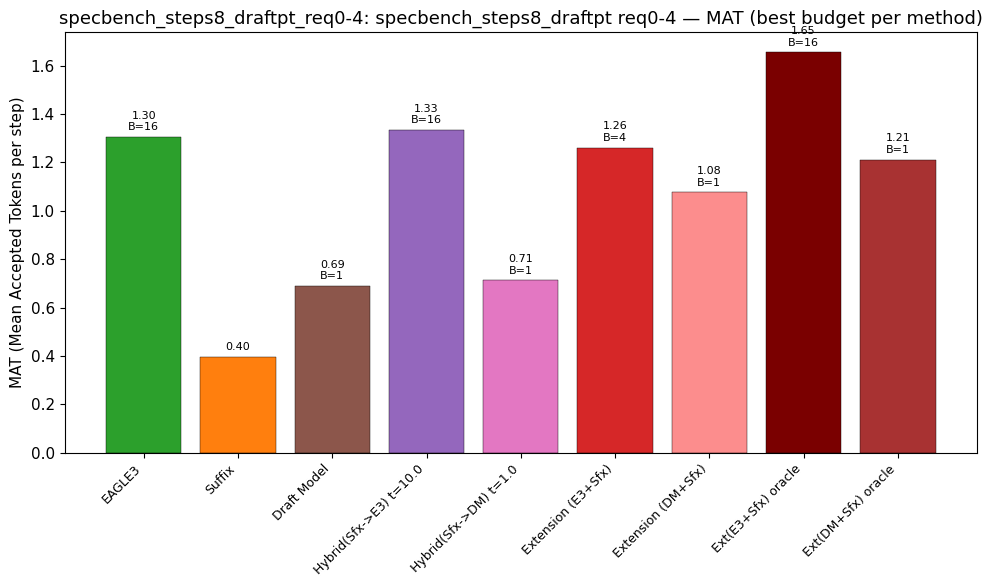

In [191]:
mdf_mat = mdf[mdf['mat'] > 0].copy()

if len(mdf_mat) > 0:
    fig, ax = plt.subplots(figsize=(max(10, len(mdf_mat) * 0.8), 6))
    
    x = np.arange(len(mdf_mat))
    bars = ax.bar(x, mdf_mat['mat'], color=mdf_mat['color'].values, edgecolor='black', linewidth=0.3)
    
    _max_b = int(df['budget'].max())
    for i, (mat, b) in enumerate(zip(mdf_mat['mat'], mdf_mat['best_budget'])):
        if int(b) == _max_b:
            txt = f'{mat:.2f}'
        else:
            txt = f'{mat:.2f}\nB={b}'
        ax.text(i, mat + 0.02, txt, ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(mdf_mat['label'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MAT (Mean Accepted Tokens per step)')
    ax.set_title(f'{SELECTED}: {workload_name} — MAT (best budget per method)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No MAT data available')

## 3. Speedup vs MAT Scatter

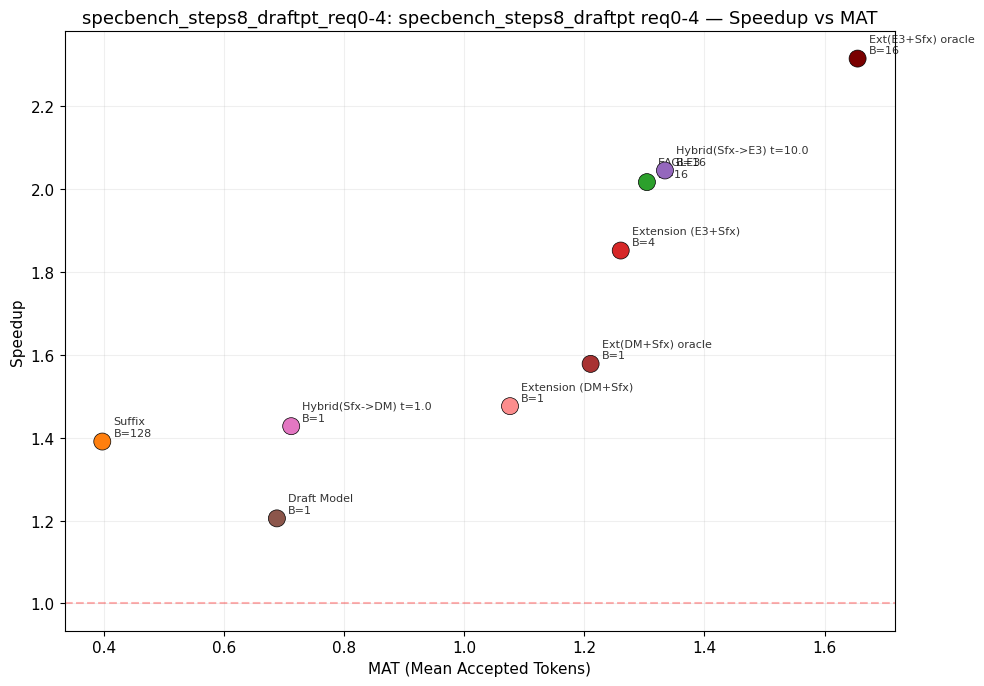

In [192]:
mdf_both = mdf[mdf['mat'] > 0].copy()

if len(mdf_both) > 0:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(mdf_both['mat'], mdf_both['speedup'],
               c=mdf_both['color'], s=150, edgecolors='black', linewidth=0.5, zorder=5)
    
    for _, r in mdf_both.iterrows():
        ax.annotate(f"{r['label']}\nB={r['best_budget']}",
                    (r['mat'], r['speedup']),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=8, alpha=0.8)
    
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel('MAT (Mean Accepted Tokens)')
    ax.set_ylabel('Speedup')
    ax.set_title(f'{SELECTED}: {workload_name} — Speedup vs MAT', fontsize=13)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print('No data')

## 4. Speedup across Ratios (Selected Budget)

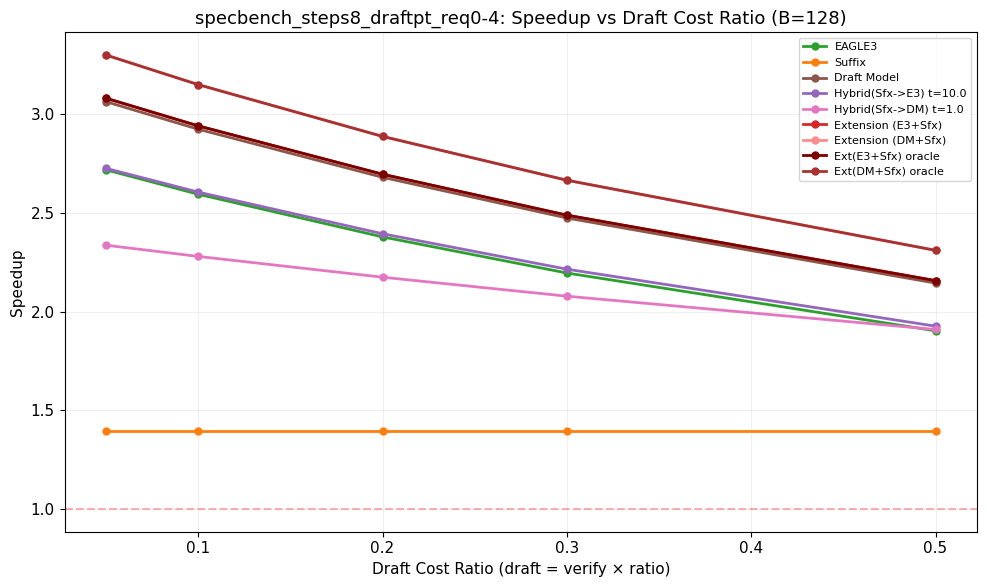

In [193]:
ratios = [0.05, 0.1, 0.2, 0.3, 0.5]
b_row = df[df['budget'] == RATIO_CHART_BUDGET]
if len(b_row) == 0:
    b_row = df.iloc[[-1]]
b_row = b_row.iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

for _, r in mdf.iterrows():
    name = r['method']
    spds = [b_row.get(f'{name}_speedup_r{ratio}', 0) for ratio in ratios]
    if any(s > 0 for s in spds):
        ax.plot(ratios, spds, 'o-', label=r['label'], color=r['color'], linewidth=2, markersize=5)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Draft Cost Ratio (draft = verify × ratio)')
ax.set_ylabel('Speedup')
ax.set_title(f'{SELECTED}: Speedup vs Draft Cost Ratio (B={int(b_row["budget"])})', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Summary Table

In [194]:
print(f"{'='*75}")
print(f"{SELECTED}: {workload_name} ({COST_LABEL})")
print(f"{'='*75}")
print()
print(f"{'Method':<32} {'Budget':>6} {'Speedup':>9} {'MAT':>6}")
print('-' * 57)
for _, r in mdf.iterrows():
    mat_str = f"{r['mat']:.2f}" if r['mat'] > 0 else '-'
    print(f"{r['label']:<32} B={r['best_budget']:>3}  {r['speedup']:>7.2f}x {mat_str:>6}")
print(f"{'='*75}")

specbench_steps8_draftpt_req0-4: specbench_steps8_draftpt req0-4 (real cost)

Method                           Budget   Speedup    MAT
---------------------------------------------------------
EAGLE3                           B= 16     2.02x   1.30
Suffix                           B=128     1.39x   0.40
Draft Model                      B=  1     1.21x   0.69
Hybrid(Sfx->E3) t=10.0           B= 16     2.04x   1.33
Hybrid(Sfx->DM) t=1.0            B=  1     1.43x   0.71
Extension (E3+Sfx)               B=  4     1.85x   1.26
Extension (DM+Sfx)               B=  1     1.48x   1.08
Ext(E3+Sfx) oracle               B= 16     2.31x   1.65
Ext(DM+Sfx) oracle               B=  1     1.58x   1.21


## 6. Budget Sensitivity (Selected Methods)

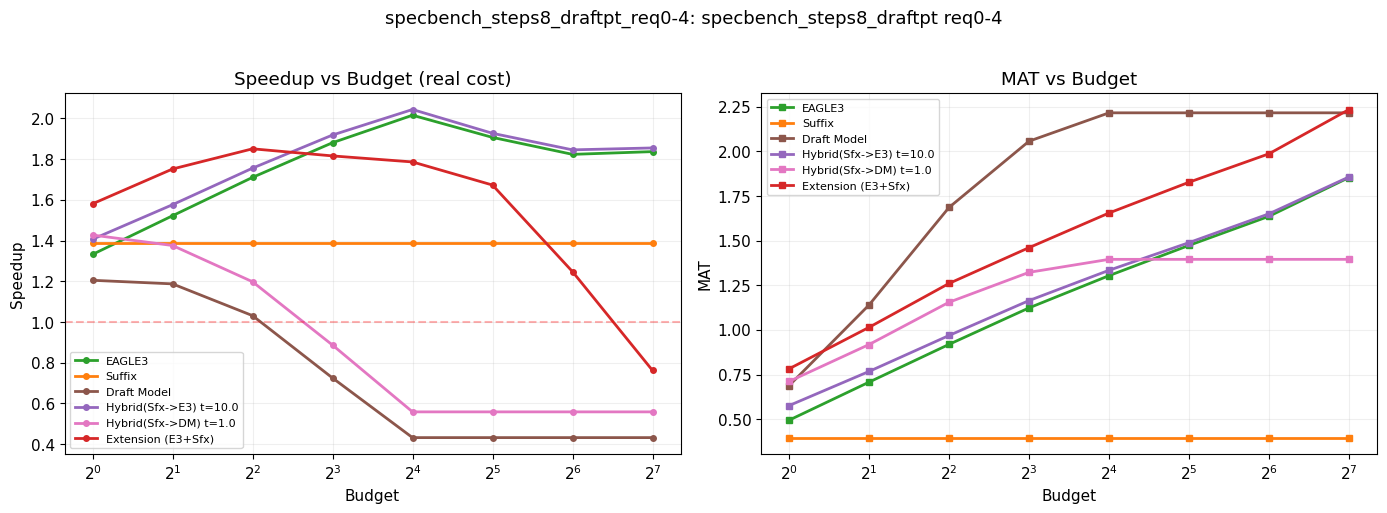

In [195]:
top_methods = mdf.head(6)['method'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in top_methods:
    col_spd = f'{name}{spd_suffix}'
    col_mat = f'{name}_mat'
    label = make_label(name)
    color = get_color(name)

    if col_spd in df.columns:
        ax1.plot(df['budget'], df[col_spd], 'o-', label=label, color=color, linewidth=2, markersize=4)
    if col_mat in df.columns:
        ax2.plot(df['budget'], df[col_mat], 's-', label=label, color=color, linewidth=2, markersize=4)

ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
ax1.set_xlabel('Budget')
ax1.set_ylabel('Speedup')
ax1.set_title(f'Speedup vs Budget ({COST_LABEL})')
ax1.set_xscale('log', base=2)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.2)

ax2.set_xlabel('Budget')
ax2.set_ylabel('MAT')
ax2.set_title('MAT vs Budget')
ax2.set_xscale('log', base=2)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

plt.suptitle(f'{SELECTED}: {workload_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Cross-steps Comparison (Same Workload, All Step Configs)

In [196]:
# Overlay speedup vs budget across the same workload's sweep axis
# (e.g. steps={2,4,6,8} for Phase 5 runs, or single-entry if only one).
HEADLINE_METHODS = ['eagle3', 'suffix', 'extension', 'extension_dmsfx', 'hybrid_e3_t5.0']

selected_workload, _sel_axis, _sel_val = _parse_dir_name(SELECTED)

# Collect all sibling configs for the same workload
peers = []
for key, (label, path) in WORKLOAD_OPTIONS.items():
    w, ax, v = _parse_dir_name(key)
    if w == selected_workload:
        peers.append((v if v is not None else 0, ax, key, label, path))
peers.sort(key=lambda x: (x[1] or '', x[0] if isinstance(x[0], int) else 0))

print(f"Workload='{selected_workload}', configs: {[k for _,_,k,_,_ in peers]}")

if len(peers) >= 2:
    fig, axes = plt.subplots(1, len(HEADLINE_METHODS),
                             figsize=(4 * len(HEADLINE_METHODS), 4.5), sharey=True)
    if len(HEADLINE_METHODS) == 1:
        axes = [axes]
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i / max(1, len(peers) - 1)) for i in range(len(peers))]

    for m_idx, m in enumerate(HEADLINE_METHODS):
        ax = axes[m_idx]
        for (v, axn, key, label, path), color in zip(peers, colors):
            with open(path) as f:
                d_i = json.load(f)
            df_i = pd.DataFrame(d_i['latency']['budget_sweep'])
            col = f'{m}{spd_suffix}'
            if col in df_i.columns:
                tag = f"{axn}={v}" if axn else key
                ax.plot(df_i['budget'], df_i[col], 'o-', color=color,
                        label=tag, linewidth=2, markersize=4)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
        ax.set_xlabel('Budget')
        if m_idx == 0:
            ax.set_ylabel('Speedup')
        ax.set_title(make_label(m))
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.suptitle(f'{selected_workload} — Speedup across configs ({COST_LABEL})',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Only 1 config for workload '{selected_workload}' — skipping sweep chart.")

Workload='specbench_steps8_draftpt', configs: ['specbench_steps8_draftpt_req0-4']
Only 1 config for workload 'specbench_steps8_draftpt' — skipping sweep chart.


## 8. Cross-workload Comparison (Same Steps, All Workloads)

In [197]:
# Overlay speedup vs budget across workloads at the SELECTED config's axis
# value (e.g. same steps for Phase 5 runs). Groups by the selected axis so
# mango3-style _req configs and Phase 5 _steps configs don't get mixed.
_sel_workload, _sel_axis, _sel_val = _parse_dir_name(SELECTED)

peers = []
for key, (label, path) in WORKLOAD_OPTIONS.items():
    w, ax, v = _parse_dir_name(key)
    if ax == _sel_axis and v == _sel_val:
        peers.append((w, key, label, path))
peers.sort()

tag = f"{_sel_axis}={_sel_val}" if _sel_axis else "(single config)"
print(f"{tag}, workloads: {[w for w,_,_,_ in peers]}")

if len(peers) >= 2:
    fig, axes = plt.subplots(1, len(HEADLINE_METHODS),
                             figsize=(4 * len(HEADLINE_METHODS), 4.5), sharey=True)
    if len(HEADLINE_METHODS) == 1:
        axes = [axes]
    cmap = plt.get_cmap('plasma')
    colors = [cmap(i / max(1, len(peers) - 1)) for i in range(len(peers))]

    for m_idx, m in enumerate(HEADLINE_METHODS):
        ax = axes[m_idx]
        for (wname, key, label, path), color in zip(peers, colors):
            with open(path) as f:
                d_i = json.load(f)
            df_i = pd.DataFrame(d_i['latency']['budget_sweep'])
            col = f'{m}{spd_suffix}'
            if col in df_i.columns:
                ax.plot(df_i['budget'], df_i[col], 'o-', color=color,
                        label=wname, linewidth=2, markersize=4)
        ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.3)
        ax.set_xlabel('Budget')
        if m_idx == 0:
            ax.set_ylabel('Speedup')
        ax.set_title(make_label(m))
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)

    plt.suptitle(f'{tag} — Speedup across workloads ({COST_LABEL})',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Need ≥2 workloads at {tag}")

req=0-4, workloads: ['specbench_steps8_draftpt']
Need ≥2 workloads at req=0-4


## 9. Extension Variants — Detailed Comparison

All extension methods side-by-side, grouped by base proposer (E3+Sfx vs
DM+Sfx) and filter family (no constraint / count / score / ptopk / product /
pathprob / oracle). The oracle variant is shown as a dashed upper-bound.

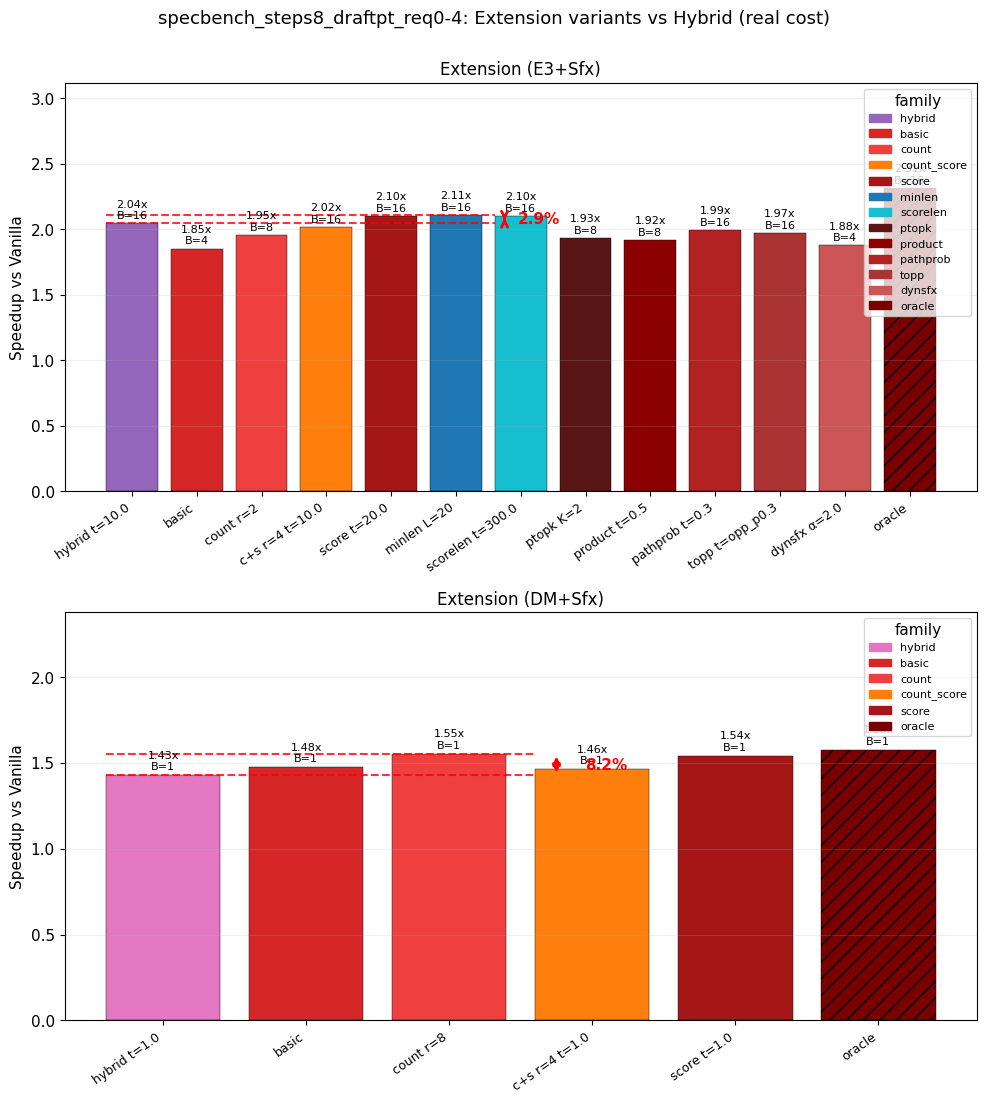


specbench_steps8_draftpt_req0-4: Best per family (extension) + hybrid baselines

[Extension (E3+Sfx)]
  family     best variant                            B     spd    mat
  hybrid     hybrid_e3_t10.0                        16   2.04x   1.33
  basic      extension                               4   1.85x   1.26
  count      extension_by_count_r2                   8   1.95x   1.23
  count_score extension_by_count_score_r4_t10.0      16   2.02x   1.46
  score      extension_by_score_t20.0               16   2.10x   1.45
  minlen     extension_by_minlen_L20                16   2.11x   1.46
  scorelen   extension_by_scorelen_t300.0           16   2.10x   1.45
  ptopk      extension_by_ptopk_k2                   8   1.93x   1.30
  product    extension_by_product_t0.5               8   1.92x   1.42
  pathprob   extension_by_pathprob_t0.3             16   1.99x   1.59
  topp       extension_by_topp_p0.3                 16   1.97x   1.41
  dynsfx     extension_by_dynsfx_a2.0                4  

In [198]:
if len(mdf_ext) == 0:
    print("No extension variants in this artifact.")
else:
    # All extension families. Per-family best variant is selected.
    FAMILY_ORDER = ['basic', 'count', 'count_score', 'score', 'minlen',
                    'scorelen', 'ptopk', 'product', 'pathprob', 'topp',
                    'dynsfx', 'oracle']
    FAMILY_COLOR = {
        'basic':       '#d62728',
        'count':       '#ef4040',
        'count_score': '#ff7f0e',
        'score':       '#a51717',
        'minlen':      '#1f77b4',
        'scorelen':    '#17becf',
        'ptopk':       '#5a1616',
        'product':     '#8b0000',
        'pathprob':    '#b22222',
        'topp':        '#aa3333',
        'dynsfx':      '#cc5555',
        'oracle':      '#7a0000',
    }
    mdf_ext = mdf_ext[mdf_ext['ext_family'].isin(FAMILY_ORDER)].copy()
    HYBRID_COLOR = {'e3': '#9467bd', 'dm': '#e377c2'}

    # Keep only the best variant per (base, family) to reduce clutter.
    best_per_fam = (
        mdf_ext.sort_values('speedup', ascending=False)
               .drop_duplicates(subset=['ext_base', 'ext_family'])
               .reset_index(drop=True)
    )

    # Pull in hybrid baselines for fair comparison — best threshold per
    # (Sfx->E3) / (Sfx->DM) family, already captured in mdf_all.
    hybrid_rows = mdf_all[mdf_all['method'].str.startswith('hybrid_')].copy()
    def _hybrid_base(m):
        if m.startswith('hybrid_e3'): return 'e3'
        if m.startswith('hybrid_dm'): return 'dm'
        return None
    hybrid_rows['ext_base'] = hybrid_rows['method'].map(_hybrid_base)
    hybrid_rows['ext_family'] = 'hybrid'

    fig, axes = plt.subplots(2, 1, figsize=(10, 11))
    bases = [('e3', 'Extension (E3+Sfx)'),
             ('dm', 'Extension (DM+Sfx)')]
    for ax, (base, title) in zip(axes, bases):
        fam_sub = best_per_fam[best_per_fam['ext_base'] == base].copy()
        hyb_sub = hybrid_rows[hybrid_rows['ext_base'] == base].copy()
        if len(fam_sub) == 0 and len(hyb_sub) == 0:
            ax.set_title(f'{title} — no data')
            ax.axis('off')
            continue

        # Hybrid first, then families in FAMILY_ORDER
        fam_sub['fam_order'] = fam_sub['ext_family'].map(
            lambda f: FAMILY_ORDER.index(f) if f in FAMILY_ORDER else 99)
        fam_sub = fam_sub.sort_values('fam_order').reset_index(drop=True)
        sub = pd.concat([hyb_sub, fam_sub], ignore_index=True)

        def _row_color(r):
            fam = r['ext_family']
            if fam == 'hybrid':
                return HYBRID_COLOR.get(r['ext_base'], '#7f7f7f')
            return FAMILY_COLOR.get(fam, '#7f7f7f')
        colors = [_row_color(r) for _, r in sub.iterrows()]

        x = np.arange(len(sub))
        bars = ax.bar(x, sub['speedup'], color=colors,
                      edgecolor='black', linewidth=0.3)
        for bar, fam in zip(bars, sub['ext_family']):
            if fam == 'oracle':
                bar.set_hatch('//')
                bar.set_edgecolor('black')

        _max_b = int(df['budget'].max())
        for i, (spd, b) in enumerate(zip(sub['speedup'], sub['best_budget'])):
            txt = f'{spd:.2f}x' if int(b) == _max_b else f'{spd:.2f}x\nB={b}'
            ax.text(i, spd + 0.02, txt, ha='center', va='bottom', fontsize=8)

        # Draw gap annotation: best realistic extension vs best hybrid.
        realistic = sub[(sub['ext_family'] != 'oracle')
                        & (sub['ext_family'] != 'hybrid')]
        hyb_rows = sub[sub['ext_family'] == 'hybrid']
        if len(realistic) > 0 and len(hyb_rows) > 0:
            # Bar positions use sub.index → integer position = .index[0]
            e_pos = realistic['speedup'].idxmax()
            h_pos = hyb_rows['speedup'].idxmax()
            e_spd = float(realistic.loc[e_pos, 'speedup'])
            h_spd = float(hyb_rows.loc[h_pos, 'speedup'])
            pct = abs((h_spd - e_spd) / max(h_spd, e_spd) * 100)

            x_lo = min(e_pos, h_pos)
            x_hi = max(e_pos, h_pos)
            ax.hlines(h_spd, x_lo - 0.4, x_hi + 0.6, colors='red',
                      linestyles='--', alpha=0.8, linewidth=1.5)
            ax.hlines(e_spd, x_lo - 0.4, x_hi + 0.6, colors='red',
                      linestyles='--', alpha=0.8, linewidth=1.5)
            arrow_x = x_hi + 0.75
            ax.annotate('', xy=(arrow_x, e_spd), xytext=(arrow_x, h_spd),
                        arrowprops=dict(arrowstyle='<->',
                                        color='red', lw=2))
            ax.text(arrow_x + 0.2, (h_spd + e_spd) / 2, f'{pct:.1f}%',
                    ha='left', va='center', color='red',
                    fontsize=11, fontweight='bold')
            ax.set_ylim(top=max(sub['speedup'].max(), h_spd, e_spd) + 0.8)
        elif len(realistic) > 0:
            # Fallback: only dashed line if no hybrid for this base.
            rmax = realistic['speedup'].max()
            ax.axhline(y=rmax, color='red', linestyle=':',
                       alpha=0.5, linewidth=1.0)
            ax.text(len(sub) - 0.5, rmax, f'  best real {rmax:.2f}x',
                    va='center', fontsize=8, color='red')

        def _short(r):
            fam = r['ext_family']
            name = r['method']
            if fam == 'hybrid':
                t = name.split('_t')[1]
                return f'hybrid t={t}'
            if fam == 'basic':
                return 'basic'
            if fam == 'oracle':
                return 'oracle'
            # count family: name looks like by_count_r{R}
            if fam == 'count' and '_r' in name:
                r = name.rsplit('_r', 1)[1]
                return f'count r={r}'
            # count_score combo: by_count_score_r{R}_t{T}
            if fam == 'count_score':
                r = name.split('_r')[-1].split('_t')[0] if '_r' in name else '?'
                t = name.rsplit('_t', 1)[1] if '_t' in name else '?'
                return f'c+s r={r} t={t}'
            # minlen: by_minlen_L{N}
            if fam == 'minlen' and '_L' in name:
                L = name.rsplit('_L', 1)[1]
                return f'minlen L={L}'
            # scorelen: by_scorelen_t{N}
            if fam == 'scorelen' and '_t' in name:
                t = name.rsplit('_t', 1)[1]
                return f'scorelen t={t}'
            # threshold/parameter-bearing families
            if '_t' in name:
                t = name.rsplit('_t', 1)[1]
                return f'{fam} t={t}'
            if '_k' in name:
                k = name.rsplit('_k', 1)[1]
                return f'{fam} K={k}'
            if '_p' in name:
                p = name.rsplit('_p', 1)[1]
                return f'{fam} p={p}'
            if '_a' in name:
                a = name.rsplit('_a', 1)[1]
                return f'{fam} α={a}'
            return fam
        ax.set_xticks(x)
        ax.set_xticklabels([_short(r) for _, r in sub.iterrows()],
                           rotation=35, ha='right', fontsize=9)
        ax.set_title(title, fontsize=12)
        ax.set_ylabel('Speedup vs Vanilla')
        ax.grid(axis='y', alpha=0.2)

        # legend: hybrid first, then families present
        present_fams = list(sub['ext_family'].unique())
        legend_order = (['hybrid'] if 'hybrid' in present_fams else []) + \
                       [f for f in FAMILY_ORDER if f in present_fams]
        handles = []
        labels_legend = []
        for f in legend_order:
            color = (HYBRID_COLOR.get(base) if f == 'hybrid'
                     else FAMILY_COLOR.get(f, '#7f7f7f'))
            handles.append(plt.Rectangle((0, 0), 1, 1, color=color))
            labels_legend.append(f)
        ax.legend(handles, labels_legend, fontsize=8, loc='upper right',
                  title='family')

    plt.suptitle(
        f'{SELECTED}: Extension variants vs Hybrid ({COST_LABEL})',
        fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()

    # Summary table (best per family + hybrids)
    print()
    print("=" * 75)
    print(f"{SELECTED}: Best per family (extension) + hybrid baselines")
    print("=" * 75)
    for base, title in bases:
        hyb = hybrid_rows[hybrid_rows['ext_base'] == base]
        ext = best_per_fam[best_per_fam['ext_base'] == base]
        if len(hyb) == 0 and len(ext) == 0:
            continue
        print(f"\n[{title}]")
        print(f"  {'family':<10} {'best variant':<35} {'B':>5} {'spd':>7} {'mat':>6}")
        for _, r in hyb.iterrows():
            print(f"  {'hybrid':<10} {r['method']:<35} "
                  f"{int(r['best_budget']):>5} "
                  f"{r['speedup']:>6.2f}x {r['mat']:>6.2f}")
        ext_sorted = ext.copy()
        ext_sorted['fam_order'] = ext_sorted['ext_family'].map(
            lambda f: FAMILY_ORDER.index(f) if f in FAMILY_ORDER else 99)
        ext_sorted = ext_sorted.sort_values('fam_order')
        for _, r in ext_sorted.iterrows():
            print(f"  {r['ext_family']:<10} {r['method']:<35} "
                  f"{int(r['best_budget']):>5} "
                  f"{r['speedup']:>6.2f}x {r['mat']:>6.2f}")

## 11. Step Cost Composition (target vs draft)

선택한 method 의 best-speedup 구성을 원그래프로. Target forward 와 draft-only 비용을 ms 로 비교.
step 별 평균 = 총 latency / step 수.


In [ ]:
# Stacked bars: per-step cost breakdown (target + draft, in ms) for
# 5 key methods. Each bar uses that method's best-speedup budget.
# 'extension_real_best' = whichever realistic extension_* variant has
# the highest speedup (oracles excluded).

# Unified budget: the B at which eagle3 achieves its best speedup.
# All methods are evaluated at that same B so the bars are directly
# comparable (same verify budget, different draft/verify trees).
_eagle3_col = 'eagle3_speedup_real'
if _eagle3_col in df.columns:
    _UNIFIED_B = int(df.loc[df[_eagle3_col].idxmax(), 'budget'])
else:
    _UNIFIED_B = int(df['budget'].median())
print(f'Unified budget = {_UNIFIED_B} (eagle3\'s best)')

def _method_row_at_B(name, B):
    col = f'{name}_speedup_real'
    if col not in df.columns:
        return None
    sub = df[df['budget'] == B]
    if sub.empty:
        return None
    return sub.iloc[0]

def _pick_ext_real_best():
    best, best_spd = None, -1
    for c in df.columns:
        if not c.endswith('_speedup_real'):
            continue
        nm = c[:-len('_speedup_real')]
        if not nm.startswith('extension'):
            continue
        if nm.endswith('_oracle') or nm in ('extension', 'extension_dmsfx'):
            continue
        if '_dmsfx' in nm:  # skip DM base variants, focus on E3+Sfx
            continue
        v = df[c].max()
        if v is not None and v > best_spd:
            best_spd, best = v, nm
    return best

ext_real_best_name = _pick_ext_real_best()
METHOD_ENTRIES = [
    ('vanilla', 'vanilla'),
    ('eagle3', 'eagle3'),
    ('suffix', 'suffix'),
    ('extension', 'extension'),
    ('extension_real_best', ext_real_best_name or 'extension'),
    ('extension_oracle', 'extension_oracle'),
]

labels, target_ms, draft_ms, budgets, speedups = [], [], [], [], []
for label, real_name in METHOD_ENTRIES:
    if real_name == 'vanilla':
        labels.append('vanilla\n(no spec)')
        target_ms.append(vanilla_ms)
        draft_ms.append(0.0)
        budgets.append(0)
        speedups.append(1.0)
        continue
    row = _method_row_at_B(real_name, _UNIFIED_B)
    if row is None:
        labels.append(label + '\n(missing)')
        target_ms.append(0); draft_ms.append(0)
        budgets.append(0); speedups.append(0)
        continue
    B = int(row['budget'])
    steps = int(row.get(f'{real_name}_steps', 0)) or 1
    t = float(row.get(f'{real_name}_total_target_ms', 0)) / steps
    d = float(row.get(f'{real_name}_total_draft_ms', 0)) / steps
    spd = float(row.get(f'{real_name}_speedup_real', 0))
    disp_name = real_name if label == 'extension_real_best' else ''
    labels.append(f'{label}' + (f'\n({disp_name})' if disp_name else ''))
    target_ms.append(t); draft_ms.append(d)
    budgets.append(B); speedups.append(spd)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x, target_ms, color='#1f77b4', edgecolor='black',
            label='target (ms)')
b2 = ax.bar(x, draft_ms, bottom=target_ms, color='#ff7f0e',
            edgecolor='black', label='draft (ms)')

for i, (t, d, B, spd) in enumerate(zip(target_ms, draft_ms, budgets, speedups)):
    total = t + d
    if total <= 0:
        continue
    if t > 0:
        ax.text(i, t / 2, f'{t:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    if d > 0:
        ax.text(i, t + d / 2, f'{d:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    ax.text(i, total + max(target_ms + draft_ms) * 0.02,
            f'total {total:.1f} ms\nB={B}, spd={spd:.2f}x',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Per-step latency (ms)')
ax.set_title(f'{SELECTED}: per-step cost breakdown at B={_UNIFIED_B} (target + draft)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## 12. Draft vs Accept Tokens per Step

Target forward 에 들어간 draft token 수 vs 실제로 accept 된 token 수 (step 평균).
Accept / draft 비율은 spec decoding 의 효율성 지표.


In [ ]:
# Stacked bars: per-step draft token split (accepted vs rejected) for
# the same 5 methods. Draft tokens = tree size fed into target forward.
# Accepted = MAT. Rejected = draft_tokens − MAT.

def _token_row(name):
    # Use unified budget (from §11) so bars line up.
    col = f'{name}_speedup_real'
    if col not in df.columns:
        return None, None, None
    sub = df[df['budget'] == _UNIFIED_B]
    if sub.empty:
        return None, None, None
    r = sub.iloc[0]
    steps = int(r.get(f'{name}_steps', 0)) or 1
    dt_col = f'{name}_total_target_tokens'
    mat = float(r.get(f'{name}_mat', 0))
    if dt_col in df.columns:
        draft_tokens = float(r[dt_col]) / steps
    else:
        draft_tokens = float(r['budget'])
    return draft_tokens, mat, int(r['budget'])

labels, accepted, rejected, budgets = [], [], [], []
for label, real_name in METHOD_ENTRIES:
    if real_name == 'vanilla':
        # vanilla has no draft tokens (single-token decode). Show bar=0.
        labels.append('vanilla\n(no spec)')
        accepted.append(1.0); rejected.append(0.0); budgets.append(0)
        continue
    dt, mat, B = _token_row(real_name)
    if dt is None:
        labels.append(label + '\n(missing)')
        accepted.append(0); rejected.append(0); budgets.append(0)
        continue
    rej = max(0.0, dt - mat)
    disp_name = real_name if label == 'extension_real_best' else ''
    labels.append(f'{label}' + (f'\n({disp_name})' if disp_name else ''))
    accepted.append(mat); rejected.append(rej); budgets.append(B)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x, accepted, color='#2ca02c', edgecolor='black', label='accepted (MAT)')
ax.bar(x, rejected, bottom=accepted, color='#d62728', edgecolor='black',
       label='rejected')

for i, (a, r, B) in enumerate(zip(accepted, rejected, budgets)):
    total = a + r
    if total <= 0:
        continue
    if a > 0:
        ax.text(i, a / 2, f'{a:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    if r > 0:
        ax.text(i, a + r / 2, f'{r:.1f}', ha='center', va='center',
                color='white', fontsize=10, fontweight='bold')
    pct = 100 * a / total if total > 0 else 0
    ax.text(i, total + max(accepted + rejected) * 0.02,
            f'draft={total:.1f} tok\naccept={pct:.1f}%  B={B}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Tokens per step')
ax.set_title(f'{SELECTED}: per-step draft tokens at B={_UNIFIED_B} (accepted vs rejected)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## 13. 기법 구현 상세

각 기법이 **Stage 6 Oracle Simulator** (`simulation/evaluation/run_tree_oracle_sim.py`)
에서 어떻게 구현되었는지 간단히 정리. 모든 기법은 동일한 trajectory
(EAGLE3 trace + Suffix cache + draft-model drafts) 위에서 budget B
(verifier slot 수) 를 놓고 speedup 을 계산한다.

### 0) 베이스라인 (single proposer)

| 기법 | 제안 트리 | 검증 로직 |
|---|---|---|
| `EAGLE3` (single:eagle3) | 최대 B 개의 노드 (step × topk) | Verify 1 회; accept 만큼 커밋 |
| `Suffix` (single:suffix) | SuffixDecodingCache.speculate() 의 tree 그대로 | 동일 |
| `Draft Model` (single:draft_model) | 길이 min(B, 16) 의 chain | 동일 |

### 1) Hybrid (Sfx → E3 / Sfx → DM)

**아이디어**: suffix 가 현재 step 에서 긴 체인을 만들어낼 수 있으면 (score ≥ threshold t) **suffix 트리**를 verify, 아니면 base proposer 트리를 verify.

- 한 step 당 Verify 는 1 회 뿐이므로 이전 검증 비용을 두 배로 쓰지 않음.
- `hybrid_*_always` variant 는 score 와 무관하게 항상 suffix 쓰는 것 — 비교용.
- threshold t ∈ {1, 2, 3, 5, 10, 20} 스위프, main chart 에는 각 base 별 최고 threshold 만 남김.

### 2) Extension (base tree + suffix 를 모든 노드에 확장)

**아이디어**: E3 트리(또는 DM chain)의 **각 노드 끝에 suffix draft 를 붙여** 한 번의 target verify 로 검증. Base 트리의 어떤 노드가 accept 되든, 그 뒤의 suffix 체인까지 한 스텝에 같이 accept 가능.

- **no constraint** (`extension`, `extension_dmsfx`): base tree 의 **모든** 노드에 suffix 확장.
- **oracle** (`extension_oracle`, `extension_dmsfx_oracle`): 실제로 accept 된 경로에만 suffix 붙였다고 가정한 **upper bound** — 배포 불가능, 성능 천장 측정용.

### 3) Extension — filter variants (어느 노드에 suffix 붙일까)

E3 트리 위에서 **어떤 노드에 한해서만** suffix 확장을 하느냐로 여러 파생.

**공통 재료**:
- `suffix_draft.score`: SuffixDecodingCache 가 반환하는 draft chain 의
  빈도/점수 (pre-verify 에 이미 알려진 값, realistic).

| family | 필터 조건 | 의도 |
|---|---|---|
| `count` | 총 tree size ≤ **C = budget** — base tree 에서 시작해 suffix extension 을 순차 attach 하다 cap 에 도달하면 stop | 전체 tree 크기를 budget 으로 직접 제한 |
| `score` (t ∈ {1,2,3,5,10,20}) | `suffix_draft.score ≥ t` 인 노드만 | suffix 체인이 충분히 길 때만 붙임 |

> **참고 — 미표시 (oracle-assisted)**: 원래 구현에는 `ptopk`, `product`,
> `pathprob`, `topp`, `dynsfx` 5개 family 가 더 있으나, 이들은 target
> model 의 verify softmax (Stage 1 에서 capture 한 `target_p_t`) 를
> 필터 입력으로 사용. 실제 배포에서는 tree 를 **고르기 전** 에 이 값을
> 알 수 없으므로 unrealistic. 현재 차트에서 제외, artifact 에는 그대로
> 남아 있음.

### 4) 검증 비용 모델 (real cost)

- Target forward: `target_forward_ms[min(B, actual_tree_size)]` — 실제 verify 한 tree size 만큼만 과금. Budget 을 초과한 경우 interp/extrap.
- Draft only:
  - EAGLE3: `eagle3_draft_ms[B]`
  - Suffix: 0ms (CPU speculate, negligible vs GPU step)
  - Draft Model: `min(B, 16) × draft_lm_tpot_ms`
- Step = target + draft. Speedup = `N_steps(vanilla) × vanilla_step_ms / Σ step_i`.

### 5) MAT (Mean Accepted Tokens)

한 step 당 `accept_length + 1` 토큰이 커밋. MAT = 총 커밋 토큰 / step 수. Speedup 의 상한선 (if draft 가 무료라면 speedup ≈ MAT).
